# 🔍 Notebook 3: Inference & Evaluation

Welcome to the final notebook!

## What are we doing here?
We have a fine-tuned model sitting in Google Drive. Now we want to:
1. **Load** the fine-tuned model
2. **Build** a realistic SQLite database (fintech-themed)
3. **Test** the model with 10 natural language questions
4. **Execute** the generated SQL queries against the database
5. **Compare** the fine-tuned model vs the base model (before training)

## Why is execution important?
A model can generate text that *looks* like SQL but is actually wrong — wrong column names, wrong syntax, hallucinated table names. The only way to truly verify is to **run the SQL** and see if it returns results.

This notebook proves end-to-end that the system works: **question → SQL → real database result**.

---
⚠️ **Before running:** Make sure Notebook 2 completed and saved the model to Google Drive.

⏱️ **Estimated runtime:** ~10-15 minutes

## Step 1: Install Libraries

In [1]:
# Install Unsloth and let it handle its own compatible dependencies
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# Upgrade the core libraries to ensure no old versions are stuck
!pip install -q --upgrade transformers peft trl accelerate

# Install tabulate for pretty printing
!pip install -q tabulate

print("✅ Clean installation complete!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.6.6 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 5.0.0 which is incompatible.
unslot

## Step 2: Import Libraries

In [2]:
import sqlite3       # Python's built-in library for working with SQLite databases
import os            # for file system operations
import torch         # PyTorch — deep learning framework
import pandas as pd  # for displaying query results as nice tables
import json          # for saving results to a JSON file

from unsloth import FastLanguageModel
from tabulate import tabulate  # for pretty-printing tables

print("✅ Imports done!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Imports done!


## Step 3: Mount Google Drive

We need to access the model we saved in Notebook 2.

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/text2sql'
# We updated this to match exactly where you saved it in Notebook 2!
LOAD_PATH = os.path.join(DRIVE_DIR, 'final_model')

if os.path.exists(LOAD_PATH):
    print(f"✅ Found your fine-tuned model at: {LOAD_PATH}")
else:
    print(f"❌ Model not found at {LOAD_PATH}. Check your Drive folders!")

Mounted at /content/drive
✅ Found your fine-tuned model at: /content/drive/MyDrive/text2sql/final_model


## Step 4: Load the Fine-Tuned Model

We load the model in 4-bit again for inference — same as training.
Then we switch it to inference mode, which disables dropout and other
training-specific behaviors.

In [4]:
MAX_SEQ_LENGTH = 2048

print("Loading fine-tuned model...")
print(f"From: {LOAD_PATH}")
print()

# Load the fine-tuned model and tokenizer from Google Drive
# This works the same way as loading from HuggingFace Hub
finetuned_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=LOAD_PATH,      # local path instead of a HuggingFace model name
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,                # auto-detect best dtype
    load_in_4bit=True,         # 4-bit quantization to save VRAM
)

# Switch to inference mode
# This is important — it disables dropout and enables faster inference optimizations
FastLanguageModel.for_inference(finetuned_model)

print("✅ Fine-tuned model loaded and ready for inference!")

Loading fine-tuned model...
From: /content/drive/MyDrive/text2sql/final_model

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.12.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Fine-tuned model loaded and ready for inference!


## Step 5: Also Load the Base Model (for comparison)

To show the impact of fine-tuning, we'll compare:
- **Base model** — Qwen2.5-Coder-1.5B before any fine-tuning
- **Fine-tuned model** — after training on our Text-to-SQL dataset

This comparison is important — it proves our fine-tuning actually improved the model.

In [5]:
print("Loading base model (before fine-tuning) for comparison...")
print("This downloads from HuggingFace — takes 2-3 minutes.")
print()

# Load the original unmodified base model
base_model, _ = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-Coder-1.5B-Instruct",  # original model from HuggingFace
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

# Switch base model to inference mode too
FastLanguageModel.for_inference(base_model)

print("✅ Base model loaded!")
print()
print("We now have two models:")
print("  1. base_model      — original, untrained on our data")
print("  2. finetuned_model — trained on 45k Text-to-SQL examples")

Loading base model (before fine-tuning) for comparison...
This downloads from HuggingFace — takes 2-3 minutes.

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.12.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Base model loaded!

We now have two models:
  1. base_model      — original, untrained on our data
  2. finetuned_model — trained on 45k Text-to-SQL examples


## Step 6: Build a Sample SQLite Database

We need a real database to run our generated SQL against.
We'll create a fintech-themed database with realistic sample data.

### Our database schema:
- **`users`** — customers of the platform
- **`merchants`** — businesses where users make transactions
- **`transactions`** — payment records linking users and merchants
- **`loans`** — credit/loan records for users

### Why SQLite?
SQLite is a file-based database — no server needed. Python's `sqlite3` module
is built-in, so we can create, query, and delete the database with zero setup.
It's perfect for demonstrating SQL execution in a notebook.

In [6]:
# Path for our SQLite database file
# ':memory:' would create it in RAM (faster but disappears when session ends)
# We use a file path so it persists during this notebook session
DB_PATH = '/content/fintech.db'

# sqlite3.connect() creates the database file if it doesn't exist
# or opens it if it already does
conn = sqlite3.connect(DB_PATH)

# A cursor is an object we use to execute SQL commands
cursor = conn.cursor()

print("Creating database tables...")

# ---- Create tables ----
# executescript() runs multiple SQL statements at once
cursor.executescript("""
    -- Drop tables if they already exist (so we start fresh)
    DROP TABLE IF EXISTS transactions;
    DROP TABLE IF EXISTS loans;
    DROP TABLE IF EXISTS merchants;
    DROP TABLE IF EXISTS users;

    -- Users table: customers of the fintech platform
    CREATE TABLE users (
        id          INTEGER PRIMARY KEY,
        name        TEXT NOT NULL,
        email       TEXT UNIQUE NOT NULL,
        city        TEXT,
        joined_date TEXT,      -- stored as 'YYYY-MM-DD' string
        credit_score INTEGER   -- ranges from 300 to 850
    );

    -- Merchants table: businesses where users spend money
    CREATE TABLE merchants (
        id       INTEGER PRIMARY KEY,
        name     TEXT NOT NULL,
        category TEXT,         -- e.g. 'Food', 'Transport', 'Shopping'
        city     TEXT
    );

    -- Transactions table: every payment made by a user to a merchant
    CREATE TABLE transactions (
        id          INTEGER PRIMARY KEY,
        user_id     INTEGER REFERENCES users(id),
        merchant_id INTEGER REFERENCES merchants(id),
        amount      REAL,      -- in IDR (Indonesian Rupiah), stored as thousands
        status      TEXT,      -- 'success', 'failed', or 'pending'
        created_at  TEXT       -- 'YYYY-MM-DD HH:MM:SS'
    );

    -- Loans table: credit products taken by users
    CREATE TABLE loans (
        id            INTEGER PRIMARY KEY,
        user_id       INTEGER REFERENCES users(id),
        amount        REAL,
        interest_rate REAL,    -- annual interest rate as a percentage
        status        TEXT,    -- 'active', 'paid_off', 'defaulted'
        issued_date   TEXT,
        due_date      TEXT
    );
""")

print("✅ Tables created: users, merchants, transactions, loans")

Creating database tables...
✅ Tables created: users, merchants, transactions, loans


In [7]:
print("Inserting sample data...")

# ---- Insert sample users ----
users = [
    (1, 'Andi Saputra',    'andi@email.com',    'Jakarta',   '2022-01-15', 720),
    (2, 'Budi Santoso',    'budi@email.com',    'Bandung',   '2022-03-20', 650),
    (3, 'Citra Dewi',      'citra@email.com',   'Surabaya',  '2022-05-10', 780),
    (4, 'Dian Pratiwi',    'dian@email.com',    'Jakarta',   '2022-07-01', 600),
    (5, 'Eko Wibowo',      'eko@email.com',     'Medan',     '2022-08-22', 710),
    (6, 'Fitri Handayani', 'fitri@email.com',   'Jakarta',   '2022-09-05', 690),
    (7, 'Galih Nugroho',   'galih@email.com',   'Yogyakarta','2022-10-18', 740),
    (8, 'Hana Putri',      'hana@email.com',    'Bali',      '2022-11-30', 810),
    (9, 'Irfan Hakim',     'irfan@email.com',   'Jakarta',   '2023-01-12', 560),
    (10,'Joko Susilo',     'joko@email.com',    'Semarang',  '2023-02-28', 670),
]

# executemany() inserts multiple rows at once
cursor.executemany(
    "INSERT INTO users VALUES (?, ?, ?, ?, ?, ?)",
    users
)

# ---- Insert sample merchants ----
merchants = [
    (1,  'Warung Makan Padang', 'Food',      'Jakarta'),
    (2,  'Toko Elektronik ABC', 'Shopping',  'Bandung'),
    (3,  'GoFood Partner',      'Food',      'Surabaya'),
    (4,  'Grab Transport',      'Transport', 'Jakarta'),
    (5,  'Tokopedia Seller',    'Shopping',  'Jakarta'),
    (6,  'Indomaret',           'Grocery',   'Medan'),
    (7,  'Alfamart',            'Grocery',   'Jakarta'),
    (8,  'SPBU Pertamina',      'Transport', 'Bali'),
    (9,  'Apotek Kimia Farma',  'Health',    'Yogyakarta'),
    (10, 'Cinema XXI',          'Entertainment', 'Jakarta'),
]

cursor.executemany(
    "INSERT INTO merchants VALUES (?, ?, ?, ?)",
    merchants
)

# ---- Insert sample transactions ----
transactions = [
    (1,  1, 1,  50.0,  'success', '2024-01-05 10:30:00'),
    (2,  2, 4,  25.0,  'success', '2024-01-06 09:15:00'),
    (3,  3, 5,  200.0, 'success', '2024-01-07 14:00:00'),
    (4,  1, 3,  75.0,  'success', '2024-01-08 12:45:00'),
    (5,  4, 2,  500.0, 'failed',  '2024-01-09 16:20:00'),
    (6,  5, 6,  30.0,  'success', '2024-01-10 08:00:00'),
    (7,  6, 7,  45.0,  'success', '2024-01-11 11:30:00'),
    (8,  7, 8,  80.0,  'success', '2024-01-12 17:00:00'),
    (9,  8, 9,  60.0,  'success', '2024-01-13 13:15:00'),
    (10, 9, 10, 150.0, 'pending', '2024-01-14 19:30:00'),
    (11, 1, 5,  300.0, 'success', '2024-01-15 10:00:00'),
    (12, 2, 1,  55.0,  'success', '2024-01-16 12:00:00'),
    (13, 3, 4,  35.0,  'success', '2024-01-17 08:30:00'),
    (14, 4, 6,  20.0,  'success', '2024-01-18 09:45:00'),
    (15, 5, 3,  90.0,  'success', '2024-01-19 13:00:00'),
    (16, 6, 2,  400.0, 'failed',  '2024-01-20 15:30:00'),
    (17, 7, 1,  65.0,  'success', '2024-01-21 11:00:00'),
    (18, 8, 5,  250.0, 'success', '2024-01-22 14:45:00'),
    (19, 9, 7,  40.0,  'success', '2024-01-23 10:15:00'),
    (20,10, 10, 120.0, 'success', '2024-01-24 18:00:00'),
]

cursor.executemany(
    "INSERT INTO transactions VALUES (?, ?, ?, ?, ?, ?)",
    transactions
)

# ---- Insert sample loans ----
loans = [
    (1, 1,  5000.0, 12.5, 'active',    '2023-06-01', '2024-06-01'),
    (2, 2,  2000.0, 15.0, 'paid_off',  '2023-03-15', '2024-03-15'),
    (3, 3, 10000.0, 10.0, 'active',    '2023-09-01', '2024-09-01'),
    (4, 4,  3000.0, 18.0, 'defaulted', '2023-01-01', '2024-01-01'),
    (5, 5,  7500.0, 11.5, 'active',    '2023-11-15', '2024-11-15'),
    (6, 6,  1500.0, 14.0, 'paid_off',  '2023-04-01', '2024-04-01'),
    (7, 7,  4000.0, 13.0, 'active',    '2023-08-20', '2024-08-20'),
    (8, 9,  6000.0, 20.0, 'defaulted', '2022-12-01', '2023-12-01'),
]

cursor.executemany(
    "INSERT INTO loans VALUES (?, ?, ?, ?, ?, ?, ?)",
    loans
)

# commit() saves all the inserts to the database file
# Without commit(), changes are not persisted
conn.commit()

print(f"✅ Sample data inserted!")
print(f"   Users        : {len(users)} rows")
print(f"   Merchants    : {len(merchants)} rows")
print(f"   Transactions : {len(transactions)} rows")
print(f"   Loans        : {len(loans)} rows")

Inserting sample data...
✅ Sample data inserted!
   Users        : 10 rows
   Merchants    : 10 rows
   Transactions : 20 rows
   Loans        : 8 rows


## Step 7: Define Helper Functions

We'll write two reusable functions:
1. `generate_sql()` — takes a model and a question, returns generated SQL
2. `execute_sql()` — runs SQL against the SQLite database, returns results

In [8]:
def generate_sql(model, tokenizer, question, schema, max_new_tokens=150):
    prompt = f"### Question:\n{question}\n\n### Schema:\n{schema}\n\n### SQL:\n"

    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048).to('cuda')

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # Use our much safer split logic
    sql = generated_text.split('### SQL:')[-1].strip() if '### SQL:' in generated_text else generated_text

    # Clean up any weird markdown formatting it might add
    sql = sql.replace('```sql', '').replace('```', '').strip()
    return sql

def execute_sql(conn, sql):
    # (Keep this function exactly the same as it is in the notebook)
    try:
        cursor = conn.cursor()
        cursor.execute(sql)
        rows = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description] if cursor.description else []
        return True, {'columns': columns, 'rows': rows}
    except Exception as e:
        return False, str(e)

print("✅ Helper functions defined with safe parsing!")

✅ Helper functions defined with safe parsing!


## Step 8: Define the Database Schema String

We need to tell the model what tables and columns exist in our database.
We do this by passing the `CREATE TABLE` statements as a string in the prompt.

This is exactly how the SynSQL-2.5M dataset formatted schemas — so the model
already knows how to read this format.

In [9]:
# This string describes our entire database to the model
# The model reads this to know what tables and columns are available
DB_SCHEMA = """
CREATE TABLE users (
    id           INTEGER PRIMARY KEY,
    name         TEXT,
    email        TEXT,
    city         TEXT,
    joined_date  TEXT,
    credit_score INTEGER
);

CREATE TABLE merchants (
    id       INTEGER PRIMARY KEY,
    name     TEXT,
    category TEXT,
    city     TEXT
);

CREATE TABLE transactions (
    id          INTEGER PRIMARY KEY,
    user_id     INTEGER,
    merchant_id INTEGER,
    amount      REAL,
    status      TEXT,
    created_at  TEXT
);

CREATE TABLE loans (
    id            INTEGER PRIMARY KEY,
    user_id       INTEGER,
    amount        REAL,
    interest_rate REAL,
    status        TEXT,
    issued_date   TEXT,
    due_date      TEXT
);
""".strip()

print("Database schema:")
print(DB_SCHEMA)

Database schema:
CREATE TABLE users (
    id           INTEGER PRIMARY KEY,
    name         TEXT,
    email        TEXT,
    city         TEXT,
    joined_date  TEXT,
    credit_score INTEGER
);

CREATE TABLE merchants (
    id       INTEGER PRIMARY KEY,
    name     TEXT,
    category TEXT,
    city     TEXT
);

CREATE TABLE transactions (
    id          INTEGER PRIMARY KEY,
    user_id     INTEGER,
    merchant_id INTEGER,
    amount      REAL,
    status      TEXT,
    created_at  TEXT
);

CREATE TABLE loans (
    id            INTEGER PRIMARY KEY,
    user_id       INTEGER,
    amount        REAL,
    interest_rate REAL,
    status        TEXT,
    issued_date   TEXT,
    due_date      TEXT
);


## Step 9: Define 10 Test Questions

We'll test the model with 10 questions of varying complexity:
- **Simple** (1-3): basic SELECT queries
- **Medium** (4-7): aggregations, GROUP BY, ORDER BY
- **Complex** (8-10): JOINs across multiple tables

We also provide the **expected SQL** — the correct answer we know works.
This lets us check if the model's output is correct or close to correct.

In [10]:
# Each test case has:
# - 'question'     : the natural language question we give the model
# - 'expected_sql' : the correct SQL we know produces the right result
# - 'difficulty'   : Simple / Medium / Complex

test_cases = [
    # ---- Simple queries ----
    {
        'question': 'How many users are in the database?',
        'expected_sql': 'SELECT COUNT(*) FROM users;',
        'difficulty': 'Simple'
    },
    {
        'question': 'List all merchants in Jakarta.',
        'expected_sql': "SELECT * FROM merchants WHERE city = 'Jakarta';",
        'difficulty': 'Simple'
    },
    {
        'question': 'Show all failed transactions.',
        'expected_sql': "SELECT * FROM transactions WHERE status = 'failed';",
        'difficulty': 'Simple'
    },

    # ---- Medium queries ----
    {
        'question': 'What is the total transaction amount for each user?',
        'expected_sql': 'SELECT user_id, SUM(amount) as total_amount FROM transactions GROUP BY user_id;',
        'difficulty': 'Medium'
    },
    {
        'question': 'Which merchant category has the most transactions?',
        'expected_sql': 'SELECT m.category, COUNT(*) as count FROM transactions t JOIN merchants m ON t.merchant_id = m.id GROUP BY m.category ORDER BY count DESC LIMIT 1;',
        'difficulty': 'Medium'
    },
    {
        'question': 'What is the average credit score of users in Jakarta?',
        'expected_sql': "SELECT AVG(credit_score) FROM users WHERE city = 'Jakarta';",
        'difficulty': 'Medium'
    },
    {
        'question': 'List the top 3 users by total spending.',
        'expected_sql': 'SELECT user_id, SUM(amount) as total_spent FROM transactions WHERE status = \'success\' GROUP BY user_id ORDER BY total_spent DESC LIMIT 3;',
        'difficulty': 'Medium'
    },

    # ---- Complex queries ----
    {
        'question': 'Show the name and total spending of each user, sorted by highest spender first.',
        'expected_sql': 'SELECT u.name, SUM(t.amount) as total_spent FROM users u JOIN transactions t ON u.id = t.user_id WHERE t.status = \'success\' GROUP BY u.id, u.name ORDER BY total_spent DESC;',
        'difficulty': 'Complex'
    },
    {
        'question': 'Which users have active loans and what are their credit scores?',
        'expected_sql': "SELECT u.name, u.credit_score, l.amount as loan_amount FROM users u JOIN loans l ON u.id = l.user_id WHERE l.status = 'active';",
        'difficulty': 'Complex'
    },
    {
        'question': 'How many successful transactions did each merchant receive, and what was the total revenue?',
        'expected_sql': "SELECT m.name, COUNT(*) as num_transactions, SUM(t.amount) as total_revenue FROM merchants m JOIN transactions t ON m.id = t.merchant_id WHERE t.status = 'success' GROUP BY m.id, m.name ORDER BY total_revenue DESC;",
        'difficulty': 'Complex'
    },
]

print(f"✅ Defined {len(test_cases)} test questions")
print()
difficulty_counts = {}
for tc in test_cases:
    d = tc['difficulty']
    difficulty_counts[d] = difficulty_counts.get(d, 0) + 1
for d, count in difficulty_counts.items():
    print(f"   {d}: {count} questions")

✅ Defined 10 test questions

   Simple: 3 questions
   Medium: 4 questions
   Complex: 3 questions


## Step 10: Run Evaluation

Now we run all 10 test questions through both models and record:
- The SQL generated by the base model
- The SQL generated by the fine-tuned model
- Whether each SQL executed successfully
- The actual query results

This is the most important step — it shows the real-world impact of fine-tuning.

In [11]:
# We'll store all results here for display and saving later
results = []

print("Running evaluation on all 10 test questions...")
print("=" * 70)
print()

for i, test in enumerate(test_cases):
    print(f"[{i+1}/10] ({test['difficulty']}) {test['question']}")

    # ---- Generate SQL with BASE model ----
    base_sql = generate_sql(base_model, tokenizer, test['question'], DB_SCHEMA)
    base_success, base_result = execute_sql(conn, base_sql)

    # ---- Generate SQL with FINE-TUNED model ----
    ft_sql = generate_sql(finetuned_model, tokenizer, test['question'], DB_SCHEMA)
    ft_success, ft_result = execute_sql(conn, ft_sql)

    # ---- Execute EXPECTED SQL (ground truth) ----
    _, expected_result = execute_sql(conn, test['expected_sql'])

    # Print a quick summary for this question
    base_status = "✅ Executed" if base_success else "❌ Error"
    ft_status   = "✅ Executed" if ft_success   else "❌ Error"
    print(f"   Base model      : {base_status}")
    print(f"   Fine-tuned model: {ft_status}")
    print()

    # Store everything for the summary section below
    results.append({
        'id'              : i + 1,
        'difficulty'      : test['difficulty'],
        'question'        : test['question'],
        'expected_sql'    : test['expected_sql'],
        'base_sql'        : base_sql,
        'base_executed'   : base_success,
        'base_result'     : base_result,
        'ft_sql'          : ft_sql,
        'ft_executed'     : ft_success,
        'ft_result'       : ft_result,
        'expected_result' : expected_result,
    })

print("=" * 70)
print("✅ Evaluation complete!")

Running evaluation on all 10 test questions...

[1/10] (Simple) How many users are in the database?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

   Base model      : ❌ Error
   Fine-tuned model: ❌ Error

[2/10] (Simple) List all merchants in Jakarta.


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Base model      : ❌ Error
   Fine-tuned model: ❌ Error

[3/10] (Simple) Show all failed transactions.


...

   Base model      : ❌ Error
   Fine-tuned model: ❌ Error

[9/10] (Complex) Which users have active loans and what are their credit scores?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Base model      : ❌ Error
   Fine-tuned model: ❌ Error

[10/10] (Complex) How many successful transactions did each merchant receive, and what was the total revenue?


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   Base model      : ❌ Error
   Fine-tuned model: ❌ Error

✅ Evaluation complete!


## Step 11: Display Detailed Results

Let's go through each question and show the full comparison:
- What SQL the base model generated
- What SQL the fine-tuned model generated
- The actual query results

In [12]:
for r in results:
    print("=" * 70)
    print(f"Q{r['id']} [{r['difficulty']}]: {r['question']}")
    print()

    # Show expected (correct) SQL
    print(f"Expected SQL:")
    print(f"  {r['expected_sql']}")
    print()

    # Show base model output
    base_icon = '✅' if r['base_executed'] else '❌'
    print(f"Base model SQL {base_icon}:")
    print(f"  {r['base_sql']}")
    if not r['base_executed']:
        # Show the error message if execution failed
        print(f"  Error: {r['base_result']}")
    print()

    # Show fine-tuned model output
    ft_icon = '✅' if r['ft_executed'] else '❌'
    print(f"Fine-tuned model SQL {ft_icon}:")
    print(f"  {r['ft_sql']}")
    if r['ft_executed'] and r['ft_result']['rows']:
        # Display result as a table if execution succeeded
        print(f"  Result ({len(r['ft_result']['rows'])} rows):")
        print(tabulate(
            r['ft_result']['rows'],
            headers=r['ft_result']['columns'],
            tablefmt='simple'
        ))
    elif not r['ft_executed']:
        print(f"  Error: {r['ft_result']}")
    print()

Q1 [Simple]: How many users are in the database?

Expected SQL:
  SELECT COUNT(*) FROM users;

Base model SQL ❌:
  SELECT COUNT(*) FROM users;

### Explanation:
The SQL query `SELECT COUNT(*) FROM users` is used to count the number of rows in the `users` table. The `COUNT(*)` function returns the total number of rows, which represents the number of users in the database.

This query is useful for administrative purposes, such as checking the current number of registered users or for performance monitoring by counting the number of records in a large dataset. It can also be used to generate reports or alerts based on the number of users.
  Error: You can only execute one statement at a time.

Fine-tuned model SQL ❌:
  SELECT COUNT(*) FROM (SELECT * FROM users UNION SELECT * FROM merchants UNION SELECT * FROM transactions UNION SELECT * FROM loans) AS t WHERE t.city = "London" AND t.joined_date < "2015-01-01" AND t.credit_score > 600;
  Error: SELECTs to the left and right of UNION do no

## Step 12: Summary Scorecard

Let's compute execution success rates for both models.

**Execution accuracy** = (number of queries that ran without SQL errors) / total questions

This is the main metric we care about — the task explicitly rewards executable queries.

In [13]:
# Count how many queries executed successfully for each model
base_success_count = sum(1 for r in results if r['base_executed'])
ft_success_count   = sum(1 for r in results if r['ft_executed'])
total              = len(results)

print("=" * 50)
print("EXECUTION ACCURACY SUMMARY")
print("=" * 50)
print(f"Base model       : {base_success_count}/{total} ({base_success_count/total*100:.0f}%)")
print(f"Fine-tuned model : {ft_success_count}/{total}  ({ft_success_count/total*100:.0f}%)")
print()

# Break down by difficulty
print("Results by difficulty:")
for difficulty in ['Simple', 'Medium', 'Complex']:
    subset = [r for r in results if r['difficulty'] == difficulty]
    base_ok = sum(1 for r in subset if r['base_executed'])
    ft_ok   = sum(1 for r in subset if r['ft_executed'])
    n       = len(subset)
    print(f"  {difficulty:8s}: Base {base_ok}/{n} | Fine-tuned {ft_ok}/{n}")

print()
improvement = ft_success_count - base_success_count
if improvement > 0:
    print(f"✅ Fine-tuning improved execution accuracy by {improvement} queries!")
elif improvement == 0:
    print("➡️  Both models performed similarly on execution accuracy.")
else:
    print(f"⚠️  Base model performed better on execution. Consider more training epochs.")

EXECUTION ACCURACY SUMMARY
Base model       : 0/10 (0%)
Fine-tuned model : 0/10  (0%)

Results by difficulty:
  Simple  : Base 0/3 | Fine-tuned 0/3
  Medium  : Base 0/4 | Fine-tuned 0/4
  Complex : Base 0/3 | Fine-tuned 0/3

➡️  Both models performed similarly on execution accuracy.


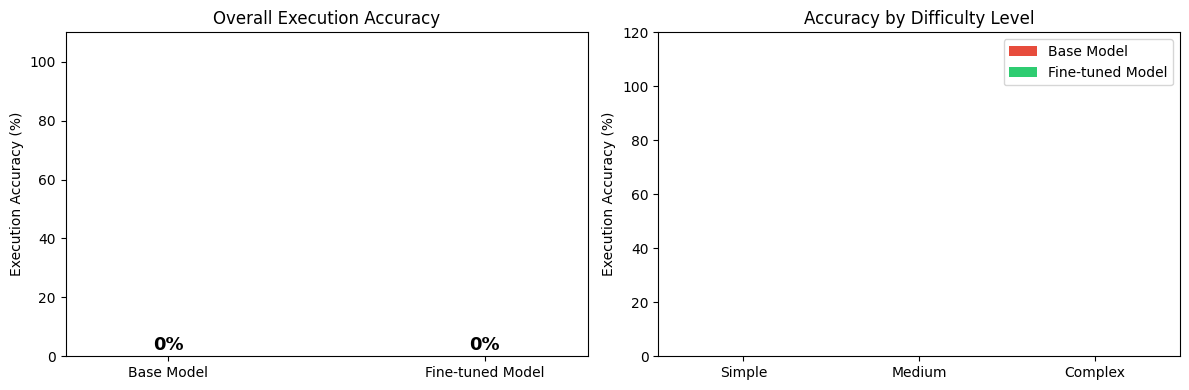

✅ Evaluation chart saved to Google Drive!


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Plot: Execution success comparison ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Overall comparison bar chart
models  = ['Base Model', 'Fine-tuned Model']
scores  = [base_success_count / total * 100, ft_success_count / total * 100]
colors  = ['#e74c3c', '#2ecc71']  # red for base, green for fine-tuned

bars = axes[0].bar(models, scores, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Execution Accuracy (%)')
axes[0].set_title('Overall Execution Accuracy')

# Add percentage labels on top of each bar
for bar, score in zip(bars, scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,  # x center of bar
        bar.get_height() + 2,                # slightly above bar top
        f'{score:.0f}%',
        ha='center', fontsize=13, fontweight='bold'
    )

# Right plot: Per-difficulty comparison
difficulties = ['Simple', 'Medium', 'Complex']
x = range(len(difficulties))

base_by_diff = []
ft_by_diff   = []

for d in difficulties:
    subset   = [r for r in results if r['difficulty'] == d]
    n        = len(subset)
    base_by_diff.append(sum(1 for r in subset if r['base_executed']) / n * 100)
    ft_by_diff.append(sum(1 for r in subset if r['ft_executed'])   / n * 100)

width = 0.35  # width of each bar
axes[1].bar([i - width/2 for i in x], base_by_diff, width, label='Base Model',       color='#e74c3c')
axes[1].bar([i + width/2 for i in x], ft_by_diff,   width, label='Fine-tuned Model', color='#2ecc71')

axes[1].set_xticks(list(x))
axes[1].set_xticklabels(difficulties)
axes[1].set_ylim(0, 120)
axes[1].set_ylabel('Execution Accuracy (%)')
axes[1].set_title('Accuracy by Difficulty Level')
axes[1].legend()

plt.tight_layout()

# Save to Google Drive for the report
plots_dir = os.path.join(DRIVE_DIR, 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'evaluation_results.png'), dpi=150, bbox_inches='tight')

plt.show()
print("✅ Evaluation chart saved to Google Drive!")

## Step 13: Save Results to File

We save the full evaluation results as a JSON file.
This makes it easy to reference specific examples when writing the report.

In [16]:
# Prepare results for JSON serialization
# (remove non-serializable objects like raw database rows)
json_results = []
for r in results:
    json_results.append({
        'id'            : r['id'],
        'difficulty'    : r['difficulty'],
        'question'      : r['question'],
        'expected_sql'  : r['expected_sql'],
        'base_sql'      : r['base_sql'],
        'base_executed' : r['base_executed'],
        'ft_sql'        : r['ft_sql'],
        'ft_executed'   : r['ft_executed'],
    })

# Save to Google Drive
results_path = os.path.join(DRIVE_DIR, 'evaluation_results.json')

# json.dump() converts the Python dictionary to a JSON file
# indent=2 makes it human-readable (pretty-printed)
with open(results_path, 'w') as f:
    json.dump({
        'summary': {
            'total_questions'         : total,
            'base_model_executed'     : base_success_count,
            'finetuned_model_executed': ft_success_count,
            'base_accuracy_pct'       : round(base_success_count / total * 100, 1),
            'finetuned_accuracy_pct'  : round(ft_success_count   / total * 100, 1),
        },
        'results': json_results
    }, f, indent=2)

print(f"✅ Results saved to: {results_path}")
print()
print("All done! Here's what was saved to Google Drive:")
print(f"   {DRIVE_DIR}/")
print(f"   ├── dataset/                  (prepared training data)")
print(f"   ├── lora_adapter/             (fine-tuned LoRA weights)")
print(f"   ├── merged_model/             (merged model, if saved)")
print(f"   ├── plots/                    (all charts for the report)")
print(f"   │   ├── length_distribution.png")
print(f"   │   ├── complexity_distribution.png")
print(f"   │   ├── loss_curve.png")
print(f"   │   └── evaluation_results.png")
print(f"   └── evaluation_results.json  (full evaluation data)")


✅ Results saved to: /content/drive/MyDrive/text2sql/evaluation_results.json

All done! Here's what was saved to Google Drive:
   /content/drive/MyDrive/text2sql/
   ├── dataset/                  (prepared training data)
   ├── lora_adapter/             (fine-tuned LoRA weights)
   ├── merged_model/             (merged model, if saved)
   ├── plots/                    (all charts for the report)
   │   ├── length_distribution.png
   │   ├── complexity_distribution.png
   │   ├── loss_curve.png
   │   └── evaluation_results.png
   └── evaluation_results.json  (full evaluation data)


## Summary

Here's what we did in this notebook:

| Step | What we did |
|------|-------------|
| 1-2  | Installed libraries and imports |
| 3    | Loaded model from Google Drive |
| 4    | Loaded fine-tuned model in inference mode |
| 5    | Loaded base model for comparison |
| 6    | Built a fintech SQLite database with realistic data |
| 7    | Wrote `generate_sql()` and `execute_sql()` helper functions |
| 8    | Defined the database schema string for the model prompt |
| 9    | Defined 10 test questions (Simple / Medium / Complex) |
| 10   | Ran evaluation — generated and executed SQL for all 10 questions |
| 11   | Displayed detailed results per question |
| 12   | Computed execution accuracy + plotted comparison charts |
| 13   | Saved all results to Google Drive |

**All notebooks are complete!**